In [35]:
from pathlib import Path
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.ox import OrderCrossover
from pymoo.operators.mutation.inversion import InversionMutation
from pymoo.operators.sampling.rnd import PermutationRandomSampling
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
import matplotlib.pyplot as plt
import numpy as np
import tsplib95

DATASETS = Path("../../../datasets")

def matrix_from_coords(coords: np.ndarray) -> np.ndarray:
    n = len(coords)
    dist = np.zeros((n, n), dtype=np.int32)
    for i in range(n):
        xi, yi = coords[i]
        for j in range(i + 1, n):
            dx = xi - coords[j, 0]
            dy = yi - coords[j, 1]
            d = np.hypot(dx, dy)
            w = int(np.floor(d + 0.5))
            dist[i, j] = w
            dist[j, i] = w
    return dist


def read_dataset(dataset):
    tsp_path = DATASETS / f"{dataset}.tsp"

    problem = tsplib95.load(str(tsp_path))
    assert problem.type == "TSP"
    assert problem.edge_weight_type == "EUC_2D"

    coords = np.array([problem.node_coords[node] for node in problem.get_nodes()], dtype=np.float64)

    dist = matrix_from_coords(coords)

    return dist


kroA100 = read_dataset("kroA100")
kroB100 = read_dataset("kroB100")
kroC100 = read_dataset("kroC100")
kroD100 = read_dataset("kroD100")
kroE100 = read_dataset("kroE100")

In [33]:
class MultiObjectiveTSP(ElementwiseProblem):
    def __init__(self, matrix_a, matrix_b):
        self.C1 = matrix_a
        self.C2 = matrix_b
        self.n_cities = len(matrix_a)

        super().__init__(
            n_var=self.n_cities,
            n_obj=2,
            n_ieq_constr=0,
            xl=0,
            xu=self.n_cities - 1,
            vtype=int
        )

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = np.sum(self.C1[x[:-1], x[1:]]) + self.C1[x[-1], x[0]]
        f2 = np.sum(self.C2[x[:-1], x[1:]]) + self.C2[x[-1], x[0]]
        out["F"] = [f1, f2]


def run(matrix_a, matrix_b, title, pop_size=1000, n_gen=500, seed=42):
    problem = MultiObjectiveTSP(matrix_a, matrix_b)
    algorithm = NSGA2(
        pop_size=pop_size,
        sampling=PermutationRandomSampling(),
        crossover=OrderCrossover(),
        mutation=InversionMutation(),
        eliminate_duplicates=True
    )

    print(f"Running NSGA2 " + title)
    res = minimize(
        problem,
        algorithm,
        ('n_gen', n_gen),
        seed=seed,
        verbose=True
    )

    n_solutions = len(res.F)
    idx_min_a = np.argmin(res.F[:, 0])
    idx_min_b = np.argmin(res.F[:, 1])
    best_a_val = res.F[idx_min_a]
    best_b_val = res.F[idx_min_b]

    print(f"Non-dominated Solutions Found: {n_solutions}")
    print("Extreme solution 1:")
    print(f"Cost A: {best_a_val[0]:.0f}")
    print(f"Cost B: {best_a_val[1]:.0f}")
    print(f"Extreme solution 2:")
    print(f"Cost A: {best_b_val[0]:.0f}")
    print(f"Cost B: {best_b_val[1]:.0f}")

    plot = Scatter(title=title + f" Iters: {n_gen}, Population: {pop_size}", labels=["Obj 1", "Obj 2"])
    plot.add(res.F, color="blue")
    plot.show()
    plt.show()


Running NSGA2 KroA100 vs KroB100
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |     1000 |      7 |             - |             -
     2 |     2000 |     14 |  0.0218199572 |         ideal
     3 |     3000 |     12 |  0.0403993081 |         ideal
     4 |     4000 |     12 |  0.1112879117 |         ideal
     5 |     5000 |     13 |  0.1230591662 |         ideal
     6 |     6000 |     13 |  0.0188999730 |         ideal
     7 |     7000 |      9 |  0.0874113189 |         ideal
     8 |     8000 |     12 |  0.0597846268 |         ideal
     9 |     9000 |     10 |  0.1484392646 |         ideal
    10 |    10000 |     10 |  0.0581634778 |         ideal
    11 |    11000 |     12 |  0.0033898305 |         ideal
    12 |    12000 |     14 |  0.0293119967 |         ideal
    13 |    13000 |     13 |  0.0933989978 |         ideal
    14 |    14000 |     11 |  0.0557173212 |         ideal
    15 |    15000 |     12 |  0.0462832141 |         ideal
    16 |    16000 |    

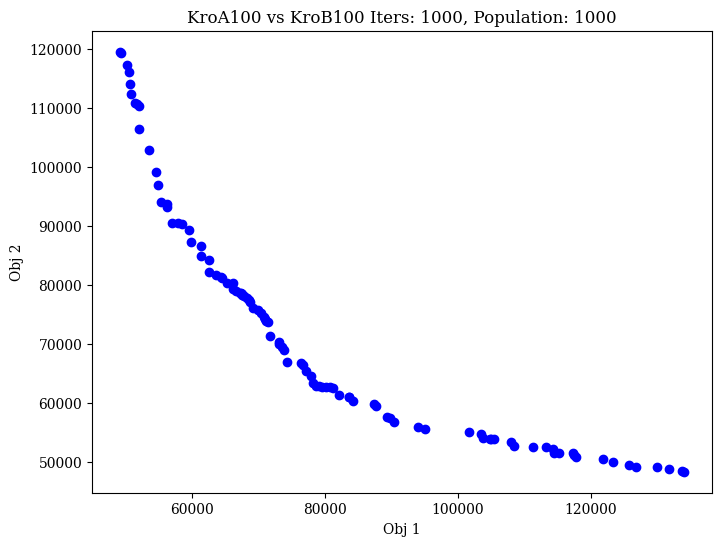

In [36]:
run(kroA100, kroB100, title="KroA100 vs KroB100", n_gen=1000, pop_size=1000, seed=1)

Running NSGA2 KroC100 vs KroE100
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |     1000 |      7 |             - |             -
     2 |     2000 |      6 |  0.2087838028 |         ideal
     3 |     3000 |      8 |  0.1704782714 |         ideal
     4 |     4000 |     12 |  0.1680804653 |         ideal
     5 |     5000 |     13 |  0.0339670454 |             f
     6 |     6000 |      9 |  0.0167627113 |         ideal
     7 |     7000 |      9 |  0.1450640971 |         ideal
     8 |     8000 |     14 |  0.0452584162 |             f
     9 |     9000 |     12 |  0.0521401062 |             f
    10 |    10000 |     16 |  0.0455289280 |             f
    11 |    11000 |     12 |  0.0334686673 |         ideal
    12 |    12000 |     15 |  0.0167811883 |             f
    13 |    13000 |     15 |  0.0642533542 |         ideal
    14 |    14000 |     16 |  0.0739692281 |         ideal
    15 |    15000 |     11 |  0.0437484655 |         ideal
    16 |    16000 |    

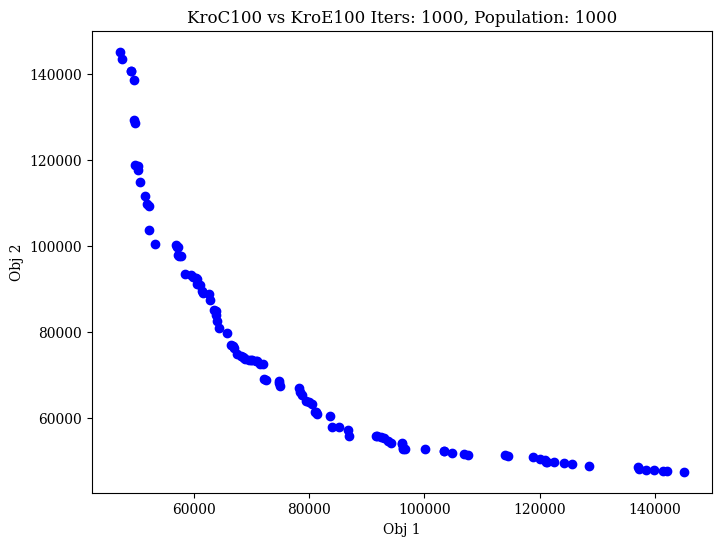

In [37]:
run(kroC100, kroE100, title="KroC100 vs KroE100", n_gen=1000, pop_size=1000, seed=1)

Running NSGA2 KroD100 vs KroE100
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |     1000 |      1 |             - |             -
     2 |     2000 |      1 |  0.000000E+00 |             f
     3 |     3000 |      1 |  6.596000E+03 |         ideal
     4 |     4000 |      1 |  0.000000E+00 |             f
     5 |     5000 |      1 |  2.112000E+03 |         ideal
     6 |     6000 |      1 |  8.289000E+03 |         ideal
     7 |     7000 |      1 |  0.000000E+00 |             f
     8 |     8000 |      1 |  2.957000E+03 |         ideal
     9 |     9000 |      1 |  2.012000E+03 |         ideal
    10 |    10000 |      1 |  2.191000E+03 |         ideal
    11 |    11000 |      1 |  0.000000E+00 |             f
    12 |    12000 |      1 |  8.720000E+02 |         ideal
    13 |    13000 |      1 |  6.600000E+01 |         ideal
    14 |    14000 |      1 |  2.570000E+03 |         ideal
    15 |    15000 |      1 |  4.654000E+03 |         ideal
    16 |    16000 |    

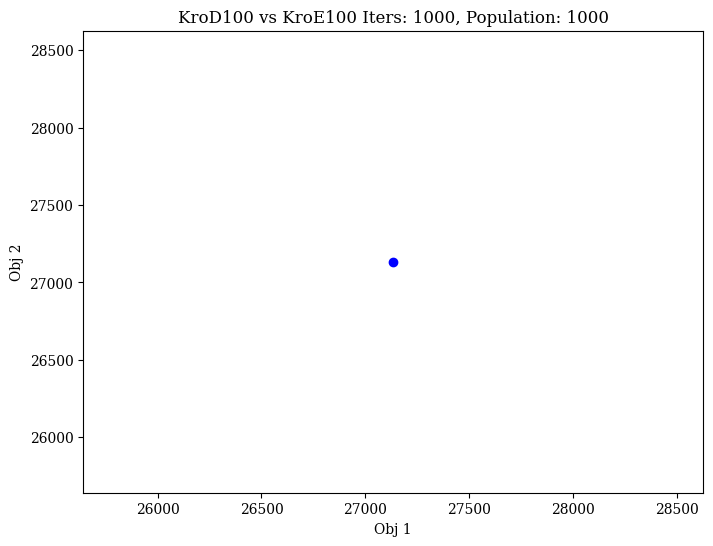

In [38]:
run(kroE100, kroE100, title="KroE100 vs KroE100", n_gen=1000, pop_size=1000, seed=1)

Running NSGA2 KroD100 vs KroE100
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |     1000 |     13 |             - |             -
     2 |     2000 |      8 |  0.2896977035 |         nadir
     3 |     3000 |      8 |  0.3188590397 |         ideal
     4 |     4000 |      9 |  0.0260150376 |         ideal
     5 |     5000 |     11 |  0.1440232360 |         ideal
     6 |     6000 |     10 |  0.1478984425 |         ideal
     7 |     7000 |     12 |  0.0740934879 |         ideal
     8 |     8000 |     14 |  0.1114249502 |         ideal
     9 |     9000 |     17 |  0.0720471631 |         ideal
    10 |    10000 |     11 |  0.1250724725 |         ideal
    11 |    11000 |     11 |  0.0048697068 |         ideal
    12 |    12000 |      6 |  0.0490474403 |             f
    13 |    13000 |     14 |  0.0970986574 |         ideal
    14 |    14000 |     16 |  0.0166732192 |             f
    15 |    15000 |     15 |  0.0201182197 |             f
    16 |    16000 |    

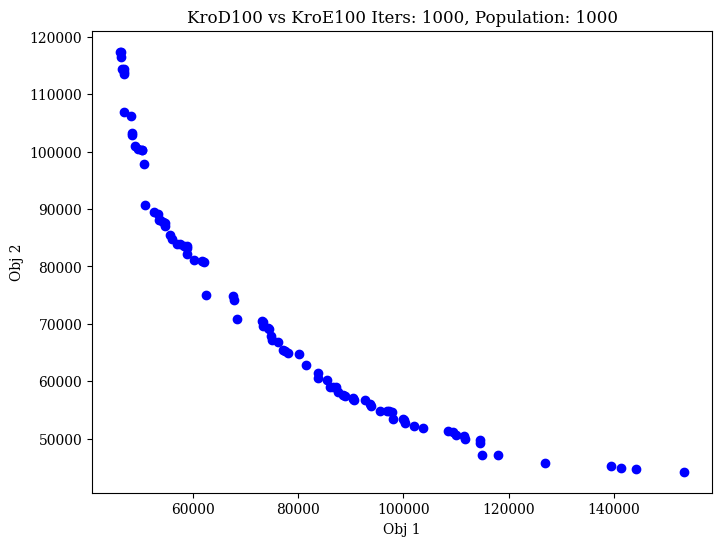

In [39]:
run(kroD100, kroE100, title="KroD100 vs KroE100", n_gen=1000, pop_size=1000, seed=1)